<a href="https://colab.research.google.com/github/roalddalhwriter/isro/blob/main/rootless.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 - Install
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.5 MB/s eta 0:00:00


In [2]:
import os
print(os.listdir("/content/drive/MyDrive/Cones/icelandplusvers"))

[]


In [ ]:
#Fix data.yaml path
import yaml

yaml_path = "/content/drive/MyDrive/Cones/icelandplusvers/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print(data)  # check what's in it before editing

# Update paths to absolute
data['path'] = "/content/drive/MyDrive/Cones/icelandplusvers"
data['train'] = "train/images"
data['val'] = "valid/images"
data['test'] = "test/images"

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("yaml updated")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Cones/icelandplusvers/data.yaml'

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import os
tiles = os.listdir("/content/drive/MyDrive/Cones/AnnotatedCones/test/images/")
print(tiles[:5])

['ESP_075860_2065_RED-abrowse3_jpg.rf.0ee0a45bc77d21c4794cc2f067ab0b2a.jpg', 'ESP_047085_2060_RED-abrowse1_jpg.rf.55c00ccf8f2b3264106b443e4a375c07.jpg', 'ESP_067525_2080_RED-abrowse2_jpg.rf.343e009b58c79bbcf967d2af886634c8.jpg']


In [ ]:
import os

label_dir = "/content/drive/MyDrive/Cones/AnnotatedCones/train/labels/"
total = 0
for f in os.listdir(label_dir):
    with open(os.path.join(label_dir, f)) as lf:
        lines = lf.readlines()
        total += len(lines)

print(f"Total annotations in train: {total}")
print(f"Total label files: {len(os.listdir(label_dir))}")

Total annotations in train: 10798
Total label files: 75


In [ ]:
import os

label_dir = "/content/drive/MyDrive/Cones/AnnotatedCones/train/labels/"
img_size = 512

widths = []
heights = []

for f in os.listdir(label_dir):
    with open(os.path.join(label_dir, f)) as lf:
        for line in lf.readlines():
            parts = line.strip().split()
            w = float(parts[3]) * img_size
            h = float(parts[4]) * img_size
            widths.append(w)
            heights.append(h)

import numpy as np
print(f"Avg cone size: {np.mean(widths):.1f} x {np.mean(heights):.1f} px")
print(f"Min cone size: {np.min(widths):.1f} x {np.min(heights):.1f} px")
print(f"Max cone size: {np.max(widths):.1f} x {np.max(heights):.1f} px")

Avg cone size: 20.3 x 25.0 px
Min cone size: 2.0 x 2.0 px
Max cone size: 510.6 x 506.9 px


In [ ]:
tiny = sum(1 for w, h in zip(widths, heights) if w < 10 or h < 10)
huge = sum(1 for w, h in zip(widths, heights) if w > 400 or h > 400)
good = sum(1 for w, h in zip(widths, heights) if 10 <= w <= 400 and 10 <= h <= 400)

print(f"Tiny (<10px):  {tiny}")
print(f"Huge (>400px): {huge}")
print(f"Good:          {good}")

Tiny (<10px):  4741
Huge (>400px): 99
Good:          5960


In [ ]:
import os

label_dir = "/content/drive/MyDrive/Cones/AnnotatedCones/test/labels/"
img_size = 512
min_px = 10
max_px = 400
removed = 0
kept = 0

for f in os.listdir(label_dir):
    path = os.path.join(label_dir, f)
    with open(path) as lf:
        lines = lf.readlines()

    clean = []
    for line in lines:
        parts = line.strip().split()
        w = float(parts[3]) * img_size
        h = float(parts[4]) * img_size
        if min_px <= w <= max_px and min_px <= h <= max_px:
            clean.append(line)
            kept += 1
        else:
            removed += 1

    with open(path, 'w') as lf:
        lf.writelines(clean)

print(f"Removed: {removed}")
print(f"Kept: {kept}")

Removed: 105
Kept: 155


In [ ]:
import os

for cache in [
    "/content/drive/MyDrive/Cones/AnnotatedCones/train/labels.cache",
    "/content/drive/MyDrive/Cones/AnnotatedCones/valid/labels.cache",
    "/content/drive/MyDrive/Cones/AnnotatedCones/test/labels.cache"
]:
    if os.path.exists(cache):
        os.remove(cache)
        print(f"Deleted: {cache}")

Deleted: /content/drive/MyDrive/Cones/AnnotatedCones/train/labels.cache
Deleted: /content/drive/MyDrive/Cones/AnnotatedCones/valid/labels.cache


In [ ]:
from PIL import Image
import os

img_dir = "/content/drive/MyDrive/Cones/NOPREPROCESS/train/images/"  # paste the path here

sizes = {}
for f in os.listdir(img_dir):
    if f.endswith(('.jpg', '.jpeg', '.png')):
        img = Image.open(os.path.join(img_dir, f))
        s = img.size
        sizes[s] = sizes.get(s, 0) + 1

for size, count in sorted(sizes.items()):
    print(f"{size}: {count} images")

(571, 851): 3 images
(652, 835): 3 images
(690, 1358): 3 images
(695, 999): 3 images
(723, 581): 3 images
(745, 681): 3 images
(756, 957): 3 images
(808, 682): 3 images
(1181, 1258): 3 images
(1415, 1015): 3 images
(1446, 756): 3 images
(1467, 674): 3 images
(1486, 627): 3 images
(1486, 947): 3 images
(1529, 1547): 3 images
(1552, 578): 3 images
(1559, 703): 3 images
(1594, 1039): 3 images
(1636, 708): 3 images
(1650, 866): 3 images
(1691, 959): 3 images
(1694, 712): 3 images
(1703, 771): 3 images
(1704, 611): 3 images
(1739, 774): 3 images


In [ ]:
import yaml

yaml_path = "/content/drive/MyDrive/Cones/icelandplusvers/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['path'] = "/content/drive/MyDrive/Cones/icelandplusvers"
data['train'] = "train/images"
data['val'] = "valid/images"
data['test'] = "test/images"

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print(data)

{'names': ['cone'], 'nc': 1, 'path': '/content/drive/MyDrive/Cones/icelandplusvers', 'roboflow': {'license': 'CC BY 4.0', 'project': 'rootlesscones-ilzho', 'url': 'https://universe.roboflow.com/lcddisplay/rootlesscones-ilzho/dataset/4', 'version': 4, 'workspace': 'lcddisplay'}, 'test': 'test/images', 'train': 'train/images', 'val': 'valid/images'}


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")
model.train(
    data=yaml_path,
    epochs=100,
    imgsz=1280,
    batch=4,
    project="/content/drive/MyDrive/Cones/runs",
    name="v2"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Cones/icelandplusvers/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015

KeyboardInterrupt: 

ESP_045384_2065_RED-abrowse2_jpg.rf.45bf1e686ee8e2821a3b7aec61aa0246.jpg

image 1/1 /content/drive/MyDrive/Cones/NOPREPROCESS/train/images/ESP_045384_2065_RED-abrowse2_jpg.rf.45bf1e686ee8e2821a3b7aec61aa0246.jpg: 608x1280 44 clusters, 24 cones, 51.0ms
Speed: 5.3ms preprocess, 51.0ms inference, 1.6ms postprocess per image at shape (1, 3, 608, 1280)


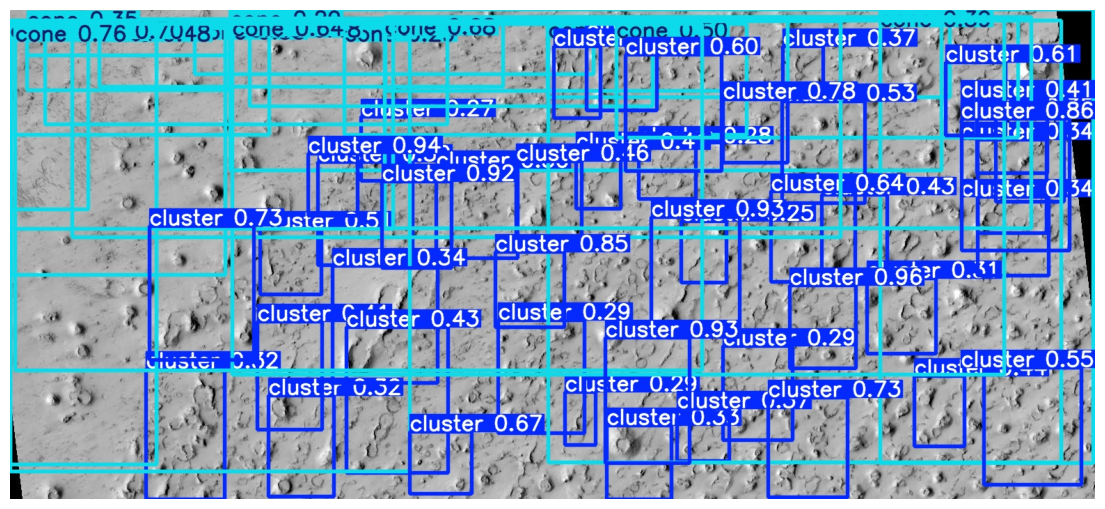

In [ ]:
train_image = "/content/drive/MyDrive/Cones/icelandplusvers/train/images/"
img_file = os.listdir(train_image)[0]
print(img_file)  # show which image it picked

results = model.predict(train_image + img_file, conf=0.25, iou=0.5)
results[0].save("/content/result_train.jpg")

img = Image.open("/content/result_train.jpg")
plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

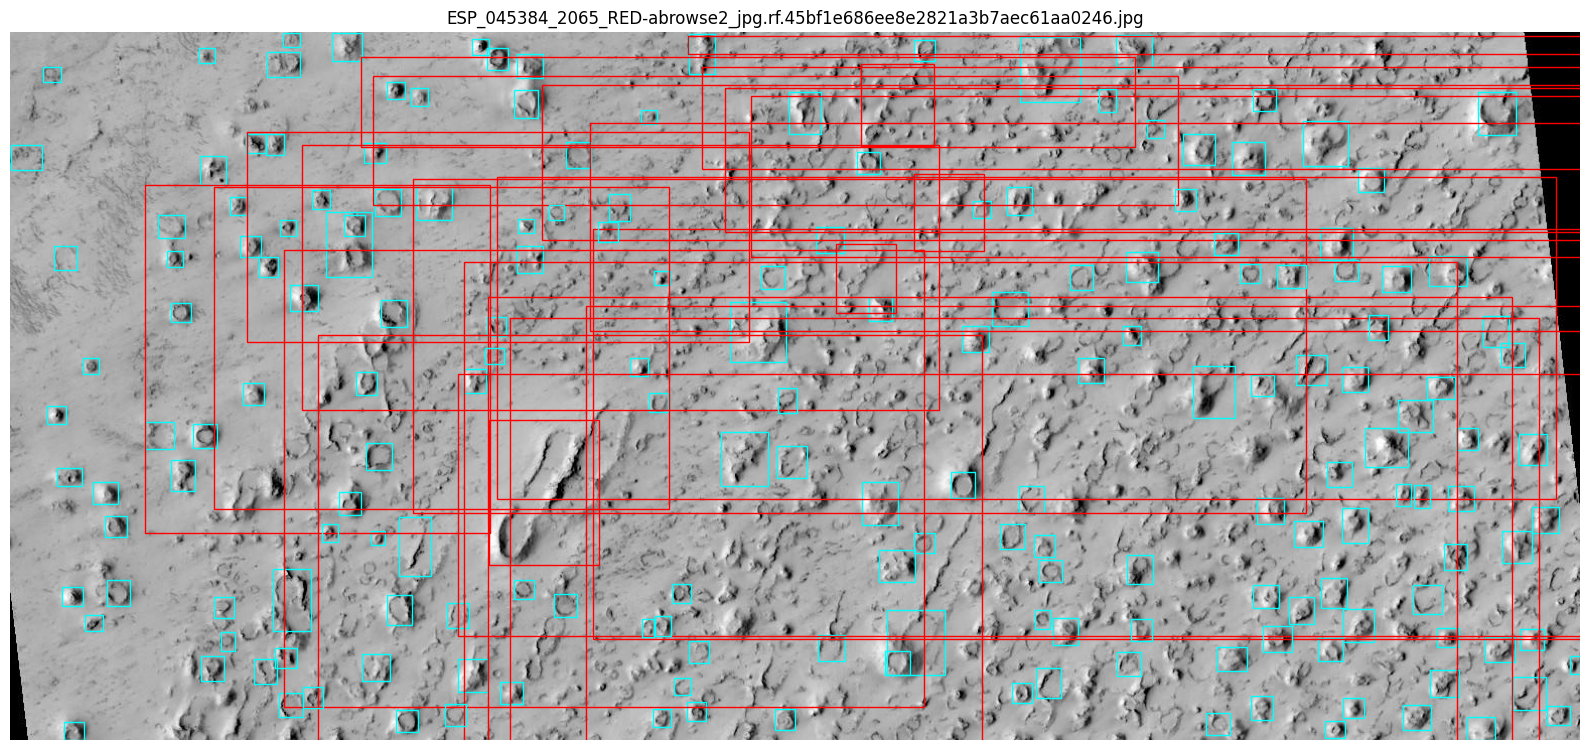

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

img_dir = "/content/drive/MyDrive/Cones/NOPREPROCESS/train/images/"
lbl_dir = "/content/drive/MyDrive/Cones/NOPREPROCESS/train/labels/"

img_file = os.listdir(img_dir)[0]
lbl_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')

img = Image.open(os.path.join(img_dir, img_file))
W, H = img.size

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.imshow(img)

colors = {0: 'red', 1: 'cyan'}

with open(os.path.join(lbl_dir, lbl_file)) as f:
    for line in f.readlines():
        parts = list(map(float, line.strip().split()))
        cls = int(parts[0])
        cx, cy, w, h = parts[1], parts[2], parts[3], parts[4]
        x = (cx - w/2) * W
        y = (cy - h/2) * H
        bw = w * W
        bh = h * H
        rect = patches.Rectangle((x, y), bw, bh,
                                   linewidth=1, edgecolor=colors[cls], facecolor='none')
        ax.add_patch(rect)

ax.set_title(img_file)
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import os

for split in ['train', 'valid', 'test']:
    label_dir = f"/content/drive/MyDrive/Cones/NOPREPROCESS/{split}/labels/"
    removed = 0
    kept = 0
    for f in os.listdir(label_dir):
        path = os.path.join(label_dir, f)
        with open(path) as lf:
            lines = lf.readlines()
        clean = [l for l in lines if not l.startswith('0')]
        removed += len(lines) - len(clean)
        kept += len(clean)
        with open(path, 'w') as lf:
            lf.writelines(clean)
    print(f"{split} — Removed: {removed} | Kept: {kept}")

train — Removed: 421 | Kept: 10396
valid — Removed: 67 | Kept: 1335
test — Removed: 24 | Kept: 236


In [ ]:
import yaml

yaml_path = "/content/drive/MyDrive/Cones/NOPREPROCESS/data.yaml"
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['nc'] = 1
data['names'] = ['cone']

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print(data)

{'names': ['cone'], 'nc': 1, 'path': '/content/drive/MyDrive/Cones/NOPREPROCESS', 'roboflow': {'license': 'CC BY 4.0', 'project': 'rootlesscones-ilzho', 'url': 'https://universe.roboflow.com/lcddisplay/rootlesscones-ilzho/dataset/3', 'version': 3, 'workspace': 'lcddisplay'}, 'test': 'test/images', 'train': 'train/images', 'val': 'valid/images'}


In [ ]:
# Check what a label file actually looks like now
lbl_dir = "/content/drive/MyDrive/Cones/NOPREPROCESS/train/labels/"
f = os.listdir(lbl_dir)[0]
with open(os.path.join(lbl_dir, f)) as lf:
    for line in lf.readlines()[:3]:
        parts = line.strip().split()
        print(f"Total values in line: {len(parts)}")
        print(parts)

Total values in line: 5
['1', '0.3153526970954357', '0.5232358003442341', '0.042876901798063624', '0.04819277108433735']
Total values in line: 5
['1', '0.17704011065006917', '0.3717728055077453', '0.027662517289073305', '0.03442340791738382']
Total values in line: 5
['1', '0.6182572614107884', '0.153184165232358', '0.029045643153526972', '0.03614457831325301']


In [ ]:
import os

for split in ['train', 'valid', 'test']:
    label_dir = f"/content/drive/MyDrive/Cones/NOPREPROCESS/{split}/labels/"
    for f in os.listdir(label_dir):
        path = os.path.join(label_dir, f)
        with open(path) as lf:
            lines = lf.readlines()
        clean = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                clean.append(' '.join(parts[:5]) + '\n')
        with open(path, 'w') as lf:
            lf.writelines(clean)

print("Done")

Done


In [ ]:
import os

for cache in [
    "/content/drive/MyDrive/Cones/NOPREPROCESS/train/labels.cache",
    "/content/drive/MyDrive/Cones/NOPREPROCESS/valid/labels.cache",
    "/content/drive/MyDrive/Cones/NOPREPROCESS/test/labels.cache"
]:
    if os.path.exists(cache):
        os.remove(cache)
        print(f"Deleted: {cache}")

Deleted: /content/drive/MyDrive/Cones/NOPREPROCESS/train/labels.cache
Deleted: /content/drive/MyDrive/Cones/NOPREPROCESS/valid/labels.cache


In [ ]:
import os

for split in ['train', 'valid', 'test']:
    label_dir = f"/content/drive/MyDrive/Cones/NOPREPROCESS/{split}/labels/"
    for f in os.listdir(label_dir):
        path = os.path.join(label_dir, f)
        with open(path) as lf:
            lines = lf.readlines()
        # Change class 1 (cone) to class 0
        fixed = []
        for line in lines:
            parts = line.strip().split()
            parts[0] = '0'
            fixed.append(' '.join(parts) + '\n')
        with open(path, 'w') as lf:
            lf.writelines(fixed)

print("Done")

Done


In [ ]:
for split in ['train', 'valid', 'test']:
    cache = f"/content/drive/MyDrive/Cones/NOPREPROCESS/{split}/labels.cache"
    if os.path.exists(cache):
        os.remove(cache)
        print(f"Deleted: {cache}")

In [ ]:
from ultralytics import YOLO

# Reload the clean base model for a full run
model = YOLO("yolov8s.pt")

model.train(
    data="/content/drive/MyDrive/Cones/icelandplusvers/data.yaml",
    epochs=100,
    imgsz=1280,
    batch=4,
    project="/content/drive/MyDrive/Cones/runs",
    name="Icelandplusvers"
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Cones/icelandplusvers/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Icelandplusvers, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d714252e4e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
!pip install sahi -q

import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sahi.predict import get_sliced_prediction
from sahi.models.ultralytics import UltralyticsDetectionModel

input_dir = "/content/drive/MyDrive/Cones/iceland"
output_dir = "/content/drive/MyDrive/Cones/iceland_predictions"
os.makedirs(output_dir, exist_ok=True)

weights_path = "/content/drive/MyDrive/Cones/runs/Icelandplusvers/weights/best.pt"

detection_model = UltralyticsDetectionModel(
    model_path=weights_path,
    confidence_threshold=0.25,
    device="cuda:0"
)

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
images = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]
print(f"Found {len(images)} Iceland images")

for idx, img_file in enumerate(images, 1):
    input_path = os.path.join(input_dir, img_file)
    output_path = os.path.join(output_dir, f"detected_{img_file}")

    print(f"[{idx}/{len(images)}] Processing: {img_file}")

    sliced_prediction = get_sliced_prediction(
        input_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.20,
        overlap_width_ratio=0.20,
        verbose=0
    )

    img = Image.open(input_path)
    fig, ax = plt.subplots(1, 1, figsize=(18, 14), dpi=150)
    ax.imshow(img)

    for op in sliced_prediction.object_prediction_list:
        xmin, ymin, xmax, ymax = op.bbox.to_xyxy()
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=1.2, edgecolor='cyan', facecolor='none'
        )
        ax.add_patch(rect)

    ax.axis('off')
    plt.title(f"{img_file} | Cones Found: {len(sliced_prediction.object_prediction_list)}", fontsize=14)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

    print(f"    -> Found {len(sliced_prediction.object_prediction_list)} cones")

print(f"\nDone! Results saved to {output_dir}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Found 12 Iceland images
[1/12] Processing: r1.jpg
    -> Found 34 cones
[2/12] Processing: r2.jpg
    -> Found 58 cones
[3/12] Processing: r3.jpg
    -> Found 55 cones
[4/12] Processing: r4.jpg
    -> Found 26 cones
[5/12] Processing: r5.jpg
    -> Found 11 cones
[6/12] Processing: r6.jpg
    -> Found 9 cones
[7/12] Processing: r7.jpg
    -> Found 59 cones
[8/12] Processing: r8.jpg
    -> Found 46 cones
[9/12] Processing: r9.jpg
    -> Found 49 cones
[10/12] Processing: r10.jpg
    -> Found 42 cones
[11/12] Processing: r11.jpg
    -> Found 19 cones
[12/12] Processing: Screenshot 2026-05-25 144143.png
    -> Found 20 cones

Done! Results saved to /content/drive/MyDrive/Cones/icelan

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

# 1. Load your optimal weights
model = YOLO("/content/drive/MyDrive/Cones/runs/v3_full_run/weights/best.pt")

# 2. Setup your test image paths
test_image_dir = "/content/drive/MyDrive/Cones/NOPREPROCESS/test/images/"
img_file = os.listdir(test_image_dir)[0]
test_image_path = os.path.join(test_image_dir, img_file)

print(f"Manually plotting clean boxes for: {img_file}")

# 3. Get the raw prediction coordinates (filtering at 0.20 confidence)
results = model.predict(test_image_path, imgsz=1280, conf=0.12, iou=0.4, verbose=False)

# 4. Open the original image to draw on top of it
img = Image.open(test_image_path)

# Create the plot environment
fig, ax = plt.subplots(1, 1, figsize=(18, 14), dpi=150)
ax.imshow(img)

# 5. Extract bounding boxes from prediction results
# boxes.xyxy contains coordinates in absolute pixels: [xmin, ymin, xmax, ymax]
boxes = results[0].boxes

for box in boxes:
    # Extract coordinates as standard floats
    xmin, ymin, xmax, ymax = map(float, box.xyxy[0])

    # Calculate width and height for matplotlib's Rectangle patch
    width = xmax - xmin
    height = ymax - ymin

    # Create a tight cyan box around the cone (No labels, no text, no clutter)
    rect = patches.Rectangle(
        (xmin, ymin), width, height,
        linewidth=1.5,
        edgecolor='cyan',
        facecolor='none'
    )
    ax.add_patch(rect)

# Render the clean image view
ax.axis('off')
plt.title(f"Clean Detections: {img_file}", fontsize=16, pad=15)
plt.tight_layout()

# Save a copy to your local directory just in case
plt.savefig("/content/result_v3_perfect_clean.jpg", bbox_inches='tight', pad_inches=0)
plt.show()

ModuleNotFoundError: No module named 'ultralytics'

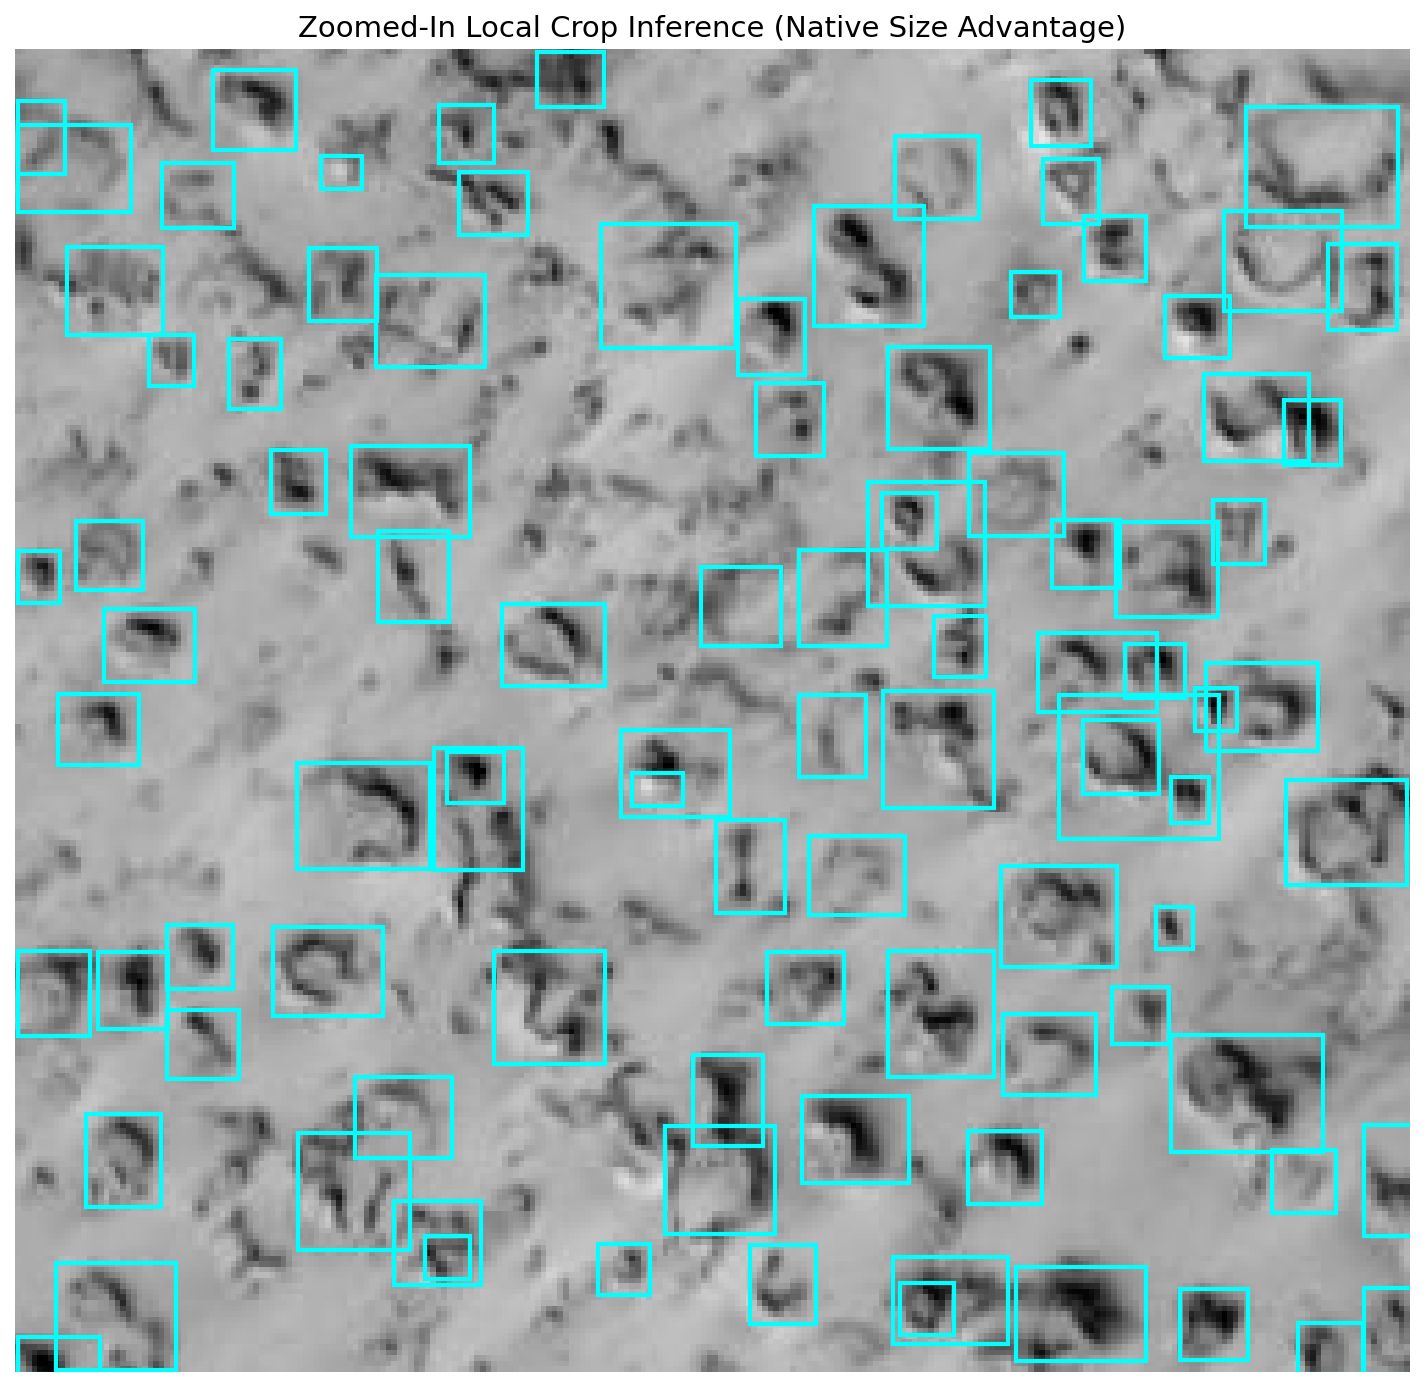

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Cones/runs/v3_full_run/weights/best.pt")
test_image_dir = "/content/drive/MyDrive/Cones/NOPREPROCESS/test/images/"
img_file = os.listdir(test_image_dir)[0]
img_path = os.path.join(test_image_dir, img_file)

# 1. Open the image and crop a small, dense cluster section (e.g., a 400x400 box)
full_img = Image.open(img_path)
W, H = full_img.size

# Slicing a localized window out of the center
crop_box = (int(W*0.3), int(H*0.3), int(W*0.6), int(H*0.6))
cropped_img = full_img.crop(crop_box)
cropped_img.save("/content/local_cluster_crop.jpg")

# 2. Run prediction on the Z00MED crop at full 1280px resolution
results = model.predict("/content/local_cluster_crop.jpg", imgsz=1280, conf=0.12, iou=0.3, verbose=False)

# 3. Plot the results
fig, ax = plt.subplots(1, 1, figsize=(12, 12), dpi=150)
ax.imshow(cropped_img)

for box in results[0].boxes:
    xmin, ymin, xmax, ymax = map(float, box.xyxy[0])
    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor='cyan', facecolor='none')
    ax.add_patch(rect)

ax.axis('off')
plt.title("Zoomed-In Local Crop Inference (Native Size Advantage)", fontsize=14)
plt.show()

In [ ]:
!pip install sahi ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sahi.predict import get_sliced_prediction
from sahi.models.ultralytics import UltralyticsDetectionModel

# 1. Map your paths
input_dir = "/content/drive/MyDrive/Cones/drive-download-20260518T040635Z-3-001"
output_dir = "/content/drive/MyDrive/Cones/v4_sahi_predictions"
os.makedirs(output_dir, exist_ok=True)

weights_path = "/content/drive/MyDrive/Cones/runs/v3_full_run/weights/best.pt"

# 2. Initialize the model engine class wrapper
detection_model = UltralyticsDetectionModel(
    model_path=weights_path,
    confidence_threshold=0.15,
    device="cuda:0"
)

# Gather target images
valid_extensions = ('.jpg', '.jpeg', '.png')
images = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]

print(f"Starting SAHI Sliced Inference on {len(images)} images...")

# 3. Loop, slice, and stitch coordinates
for idx, img_file in enumerate(images, 1):
    input_path = os.path.join(input_dir, img_file)
    output_path = os.path.join(output_dir, f"sahi_detected_{img_file}")

    print(f"[{idx}/{len(images)}] Slicing & Predicting: {img_file}")

    # Slice into 512x512 windows with a 20% spatial overlap buffer
    sliced_prediction = get_sliced_prediction(
        input_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.20,
        overlap_width_ratio=0.20,
        verbose=0
    )

    # 4. Generate clean manual plots with global stitched coordinates
    img = Image.open(input_path)
    fig, ax = plt.subplots(1, 1, figsize=(18, 14), dpi=150)
    ax.imshow(img)

    object_prediction_list = sliced_prediction.object_prediction_list

    for op in object_prediction_list:
        # Fixed attribute mapping: op.bbox replaces op.bounding_box
        xmin, ymin, xmax, ymax = op.bbox.to_xyxy()

        width = xmax - xmin
        height = ymax - ymin

        # Plot raw cyan rectangles over every cone found
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=1.2,
            edgecolor='cyan',
            facecolor='none'
        )
        ax.add_patch(rect)

    ax.axis('off')
    plt.title(f"SAHI Stitched Detections: {img_file} | Cones Found: {len(object_prediction_list)}", fontsize=14)
    plt.tight_layout()

    # Save the file out to your Google Drive directory
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)  # Keep system RAM completely clean

    print(f"    -> Complete. Found {len(object_prediction_list)} cones.")

print("\n🎉 Success! Check your 'v4_sahi_predictions' folder to see the ultra-detailed outputs.")

Starting SAHI Sliced Inference on 11 images...
[1/11] Slicing & Predicting: ESP_040162_2065_RED.abrowse.jpg
    -> Complete. Found 3362 cones.
[2/11] Slicing & Predicting: ESP_052267_2065_RED.abrowse.jpg
    -> Complete. Found 1095 cones.
[3/11] Slicing & Predicting: ESP_047085_2060_RED.abrowse.jpg
    -> Complete. Found 1420 cones.
[4/11] Slicing & Predicting: ESP_045384_2065_RED.abrowse.jpg
    -> Complete. Found 2736 cones.
[5/11] Slicing & Predicting: ESP_075860_2065_RED.abrowse.jpg
    -> Complete. Found 3007 cones.
[6/11] Slicing & Predicting: ESP_067591_2070_RED.abrowse.jpg
    -> Complete. Found 1878 cones.
[7/11] Slicing & Predicting: ESP_067525_2080_RED.abrowse.jpg
    -> Complete. Found 1178 cones.
[8/11] Slicing & Predicting: PSP_007882_2065_RED.abrowse.jpg
    -> Complete. Found 1808 cones.
[9/11] Slicing & Predicting: PSP_003900_2055_RED.abrowse.jpg
    -> Complete. Found 1379 cones.
[10/11] Slicing & Predicting: ESP_088242_2070_RED.abrowse.jpg
    -> Complete. Found 1878

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sahi.predict import get_sliced_prediction
from sahi.models.ultralytics import UltralyticsDetectionModel

# 1. Map your new inputs and outputs
input_dir = "/content/drive/MyDrive/Cones/iceland"
output_dir = "/content/drive/MyDrive/Cones/icelandpredict"
os.makedirs(output_dir, exist_ok=True)

# Pointing to your optimized v3 weights
weights_path = "/content/drive/MyDrive/Cones/runs/v3_full_run/weights/best.pt"

if not os.path.exists(input_dir):
    raise FileNotFoundError(f"Could not find the input folder at {input_dir}. Please double check the folder name inside your Drive!")

# 2. Initialize the model engine class wrapper
detection_model = UltralyticsDetectionModel(
    model_path=weights_path,
    confidence_threshold=0.12,  # Kept at 0.15 to safely harvest low-conf cluster cones
    device="cuda:0"
)

# Gather all images in the data1 directory
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
images = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]

print(f"Starting v5 SAHI Sliced Inference on {len(images)} images from: {input_dir}")
print(f"Outputs will be written to: {output_dir}\n")

# 3. Loop, slice, and stitch coordinates across your data1 batch
for idx, img_file in enumerate(images, 1):
    input_path = os.path.join(input_dir, img_file)
    output_path = os.path.join(output_dir, f"v5_detected_{img_file}")

    print(f"[{idx}/{len(images)}] Slicing & Predicting: {img_file}")

    # Slice into 512x512 windows with a 20% spatial overlap buffer
    sliced_prediction = get_sliced_prediction(
        input_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.20,
        overlap_width_ratio=0.20,
        verbose=0
    )

    # 4. Generate clean manual plots with global stitched coordinates
    img = Image.open(input_path)
    fig, ax = plt.subplots(1, 1, figsize=(18, 14), dpi=150)
    ax.imshow(img)

    object_prediction_list = sliced_prediction.object_prediction_list

    for op in object_prediction_list:
        # Verified modern property mapping
        xmin, ymin, xmax, ymax = op.bbox.to_xyxy()

        width = xmax - xmin
        height = ymax - ymin

        # Plot raw cyan rectangles over every cone found
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=1.2,
            edgecolor='cyan',
            facecolor='none'
        )
        ax.add_patch(rect)

    ax.axis('off')
    plt.title(f"v5 Sliced Detections: {img_file} | Cones Found: {len(object_prediction_list)}", fontsize=14)
    plt.tight_layout()

    # Save the file out to your v5 folder
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)  # Keep system RAM completely clean

    print(f"    -> Complete. Found {len(object_prediction_list)} cones.")

print("\n🎉 Success! All images in 'data1' have been processed. Head over to your 'v5_sahi_predictions' folder to inspect the final outputs!")

ModuleNotFoundError: No module named 'sahi'

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sahi.predict import get_sliced_prediction
from sahi.models.ultralytics import UltralyticsDetectionModel

# 1. Map paths
input_dir = "/content/drive/MyDrive/Cones/iceland"
output_dir = "/content/drive/MyDrive/Cones/icelandpredict"
os.makedirs(output_dir, exist_ok=True)

weights_path = "/content/drive/MyDrive/Cones/runs/v3_full_run/weights/best.pt"

# 2. Initialize the Martian model wrapper
detection_model = UltralyticsDetectionModel(
    model_path=weights_path,
    confidence_threshold=0.10,  # Lower threshold to adapt to Earth's atmospheric/sensor differences
    device="cuda:0"
)

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
images = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]

print(f"Running Grayscale Domain Adaptation on {len(images)} Iceland scenes...")

# 3. Process Earth images with dynamic grayscale mapping
for idx, img_file in enumerate(images, 1):
    input_path = os.path.join(input_dir, img_file)
    output_path = os.path.join(output_dir, f"iceland_gray_detected_{img_file}")

    print(f"[{idx}/{len(images)}] Preprocessing & Scanning: {img_file}")

    # Load image via OpenCV and convert to grayscale
    color_img = cv2.imread(input_path)
    gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)

    # YOLOv8 expects 3 channels even for grayscale inputs.
    # This replicates the gray single-channel across 3 channels (RGB) without adding color data.
    gray_3channel = cv2.merge([gray_img, gray_img, gray_img])

    # Save a temporary grayscale copy for SAHI to slice natively
    temp_gray_path = "/content/temp_gray_input.jpg"
    cv2.imwrite(temp_gray_path, gray_3channel)

    # Run sliced execution on the grayscale variant
    sliced_prediction = get_sliced_prediction(
        temp_gray_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.20,
        overlap_width_ratio=0.20,
        verbose=0
    )

    # 4. Generate visual outputs mapping predictions over the grayscale base
    fig, ax = plt.subplots(1, 1, figsize=(18, 14), dpi=150)
    # Display in gray map for crisp structural inspection
    ax.imshow(gray_img, cmap='gray')

    object_prediction_list = sliced_prediction.object_prediction_list

    for op in object_prediction_list:
        xmin, ymin, xmax, ymax = op.bbox.to_xyxy()
        width = xmax - xmin
        height = ymax - ymin

        # Plot cyan tracking boxes over identified pseudocraters
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=1.5,
            edgecolor='cyan',
            facecolor='none'
        )
        ax.add_patch(rect)

    ax.axis('off')
    plt.title(f"Iceland Grayscale Run: {img_file} | Cones Found: {len(object_prediction_list)}", fontsize=14)
    plt.tight_layout()

    # Save output to Drive and clear memory
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

    # Clean up local temporary file
    if os.path.exists(temp_gray_path):
        os.remove(temp_gray_path)

    print(f"    -> Complete. Found {len(object_prediction_list)} matches based on morphology.")

print("\n'iceland_predictions' folder to see how removing color improved the spatial detection!")

Running Grayscale Domain Adaptation on 1 Iceland scenes...
[1/1] Preprocessing & Scanning: Screenshot 2026-05-25 144143.png
    -> Complete. Found 104 matches based on morphology.

🎉 Success! Check out your 'iceland_predictions' folder to see how removing color improved the spatial detection!


In [ ]:
!pip install sahi -q

import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sahi.predict import get_sliced_prediction
from sahi.models.ultralytics import UltralyticsDetectionModel

input_dir = "/content/drive/MyDrive/Cones/iceland"
output_dir = "/content/drive/MyDrive/Cones/iceland_predictions"
os.makedirs(output_dir, exist_ok=True)

weights_path = "/content/drive/MyDrive/Cones/runs/Icelandplusvers/weights/best.pt"

detection_model = UltralyticsDetectionModel(
    model_path=weights_path,
    confidence_threshold=0.25,
    device="cuda:0"
)

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
images = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]
print(f"Found {len(images)} Iceland images")

for idx, img_file in enumerate(images, 1):
    input_path = os.path.join(input_dir, img_file)
    output_path = os.path.join(output_dir, f"detected_{img_file}")

    print(f"[{idx}/{len(images)}] Processing: {img_file}")

    sliced_prediction = get_sliced_prediction(
        input_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.20,
        overlap_width_ratio=0.20,
        verbose=0
    )

    img = Image.open(input_path)
    fig, ax = plt.subplots(1, 1, figsize=(18, 14), dpi=150)
    ax.imshow(img)

    for op in sliced_prediction.object_prediction_list:
        xmin, ymin, xmax, ymax = op.bbox.to_xyxy()
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=1.2, edgecolor='cyan', facecolor='none'
        )
        ax.add_patch(rect)

    ax.axis('off')
    plt.title(f"{img_file} | Cones Found: {len(sliced_prediction.object_prediction_list)}", fontsize=14)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

    print(f"    -> Found {len(sliced_prediction.object_prediction_list)} cones")

print(f"\nDone! Results saved to {output_dir}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.3 MB/s eta 0:00:00


ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
import numpy as np
from scipy.signal import find_peaks
from scipy.spatial.distance import cosine
import pandas as pd

# ──  ACTUAL DATA HERE ─────────────────────────────────────
mars_profiles = [profile1, profile2, profile3]      # list of 1D numpy arrays
iceland_profiles = [profile1, profile2, profile3]   # list of 1D numpy arrays
mars_pixel_scale = 0.25    # HiRISE resolution in meters/pixel
iceland_pixel_scale = 2.0  # ArcticDEM resolution in meters/pixel
# ──────────────────────────────────────────────────────────────────────

def normalize(p):
    return (p - p.min()) / (p.max() - p.min())

def cone_metrics(profile, pixel_scale=1.0, label=""):
    peaks, props = find_peaks(profile, prominence=5)
    valleys, _ = find_peaks(-profile)  # troughs = inverted peaks

    rim_height = profile[peaks].mean() if len(peaks) > 0 else 0
    base_elev = profile[[0, -1]].mean()  # average of endpoints
    crater_center = profile[len(profile)//2]

    cone_height = rim_height - base_elev
    crater_depth = rim_height - crater_center
    width_px = len(profile)
    width_m = width_px * pixel_scale

    return {
        "label": label,
        "rim_height_m": round(float(rim_height), 2),
        "cone_height_m": round(float(cone_height), 2),
        "crater_depth_m": round(float(crater_depth), 2),
        "width_m": round(float(width_m), 2),
        "height_to_width_ratio": round(float(cone_height / width_m) if width_m > 0 else 0, 4),
        "num_peaks": len(peaks),
    }

# ── 1. Profile shape similarity ────────────────────────────────────────
sims = []
for i, m in enumerate(mars_profiles):
    for j, ic in enumerate(iceland_profiles):
        m_r  = np.interp(np.linspace(0,1,100), np.linspace(0,1,len(m)), m)
        ic_r = np.interp(np.linspace(0,1,100), np.linspace(0,1,len(ic)), ic)
        sim  = 1 - cosine(normalize(m_r), normalize(ic_r))
        sims.append({"mars": i+1, "iceland": j+1, "cosine_sim": round(sim, 4)})

sim_df = pd.DataFrame(sims)
print("=== Profile Shape Similarity ===")
print(sim_df)
print(f"\nMean cosine similarity: {sim_df['cosine_sim'].mean():.4f}")
print(f"Min: {sim_df['cosine_sim'].min():.4f} | Max: {sim_df['cosine_sim'].max():.4f}")

# ── 2. Geometric metrics per cone ──────────────────────────────────────
mars_metrics    = [cone_metrics(p, mars_pixel_scale,    f"Mars_{i+1}")    for i, p in enumerate(mars_profiles)]
iceland_metrics = [cone_metrics(p, iceland_pixel_scale, f"Iceland_{i+1}") for i, p in enumerate(iceland_profiles)]

all_metrics = pd.DataFrame(mars_metrics + iceland_metrics)
print("\n=== Cone Geometric Metrics ===")
print(all_metrics.to_string(index=False))

# ── 3. Domain-level comparison ─────────────────────────────────────────
mars_df    = all_metrics[all_metrics['label'].str.startswith('Mars')]
iceland_df = all_metrics[all_metrics['label'].str.startswith('Iceland')]

print("\n=== Mars vs Iceland Mean Comparison ===")
cols = ['cone_height_m', 'crater_depth_m', 'width_m', 'height_to_width_ratio']
comparison = pd.DataFrame({
    'Metric':  cols,
    'Mars':    [round(mars_df[c].mean(), 3) for c in cols],
    'Iceland': [round(iceland_df[c].mean(), 3) for c in cols],
})
comparison['Ratio (Mars/Iceland)'] = round(comparison['Mars'] / comparison['Iceland'], 3)
print(comparison.to_string(index=False))

In [ ]:
!pip install sahi -q

import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sahi.predict import get_sliced_prediction
from sahi.models.ultralytics import UltralyticsDetectionModel

input_dir = "/content/drive/MyDrive/Elevation"
output_dir = "/content/drive/MyDrive/newimages"
os.makedirs(output_dir, exist_ok=True)

weights_path = "/content/drive/MyDrive/Cones/runs/Icelandplusvers/weights/best.pt"

detection_model = UltralyticsDetectionModel(
    model_path=weights_path,
    confidence_threshold=0.35,
    device="cuda:0"
)

valid_extensions = ('.jpg')
images = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]
print(f"Found {len(images)} Iceland images")

for idx, img_file in enumerate(images, 1):
    input_path = os.path.join(input_dir, img_file)
    output_path = os.path.join(output_dir, f"detected_{img_file}")

    print(f"[{idx}/{len(images)}] Processing: {img_file}")

    sliced_prediction = get_sliced_prediction(
        input_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.20,
        overlap_width_ratio=0.20,
        verbose=0
    )

    img = Image.open(input_path)
    fig, ax = plt.subplots(1, 1, figsize=(18, 14), dpi=150)
    ax.imshow(img)

    for op in sliced_prediction.object_prediction_list:
        xmin, ymin, xmax, ymax = op.bbox.to_xyxy()
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=1.2, edgecolor='cyan', facecolor='none'
        )
        ax.add_patch(rect)

    ax.axis('off')
    plt.title(f"{img_file} | Cones Found: {len(sliced_prediction.object_prediction_list)}", fontsize=14)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

    print(f"    -> Found {len(sliced_prediction.object_prediction_list)} cones")

print(f"\nDone! Results saved to {output_dir}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Found 1 Iceland images
[1/1] Processing: ortho_browse.jpg
    -> Found 818 cones

Done! Results saved to /content/drive/MyDrive/newimages


In [12]:
from ultralytics import YOLO

WEIGHTS_PATH = '/content/drive/MyDrive/Cones/runs/Icelandplusvers/weights/best.pt'
DATA_YAML    = '/content/drive/MyDrive/Cones/NOPREPROCESS/data.yaml'

model = YOLO(WEIGHTS_PATH)
metrics = model.val(data=DATA_YAML, split='train')

print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")
print(f"mAP50       : {metrics.box.map50:.4f}")
print(f"mAP50-95    : {metrics.box.map:.4f}")
print(f"Results saved to: {metrics.save_dir}")

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.3 ms, read: 0.4±0.1 MB/s, size: 173.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Cones/NOPREPROCESS/train/labels.cache... 75 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 75/75 15.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 6.1s/it 30.6s
                   all         75      10396      0.739      0.712       0.74       0.41
Speed: 11.1ms preprocess, 30.7ms inference, 0.0ms loss, 7.5ms postprocess per image
Results saved to /content/runs/detect/val-7
Precision   : 0.7385
Recall      : 0.7120
mAP50       : 0.7398
mAP50-95    : 0.4102
Results saved to: 